# Benchmark 2: latency distribution at the plateau
Write latency for every single request at the concurrency where throughput plateaus (from benchmark 1), not just an aggregate summary. Run `bench/02-latency-distribution.sh` first.

In [1]:
import sys
sys.path.insert(0, ".")
import matplotlib.pyplot as plt
from plot_style import load


In [2]:
df = load("latency-distribution.csv")
print(f"{len(df)} individual write requests captured across {df['run'].nunique()} runs "
      f"(clusterSize={df['clusterSize'].iloc[0]}, concurrency={df['concurrency'].iloc[0]})")
df.head()

8383 individual write requests captured across 3 runs (clusterSize=3, concurrency=30)


,run,clusterSize,concurrency,latencyMs
0,1,3,30,42.69
1,1,3,30,34.07
2,1,3,30,32.75
3,1,3,30,27.83
4,1,3,30,33.29


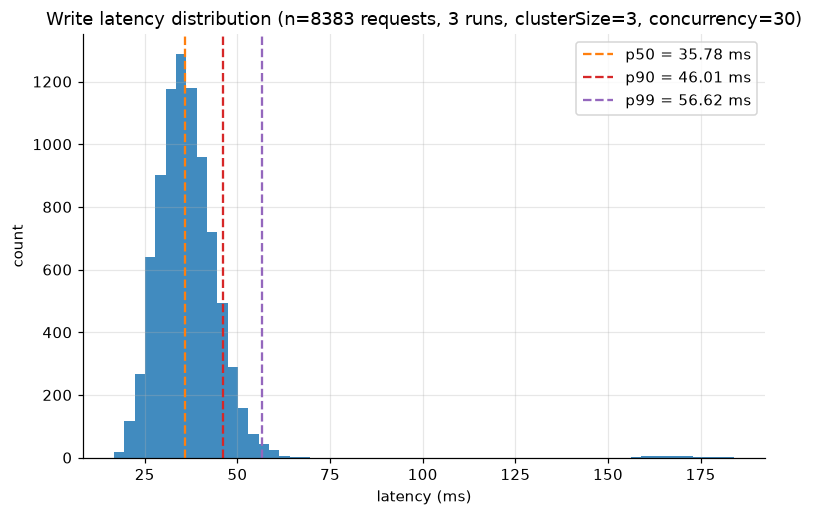

p50 = 35.78 ms
p90 = 46.01 ms
p99 = 56.62 ms


In [3]:
p50, p90, p99 = df["latencyMs"].quantile([0.5, 0.9, 0.99])

fig, ax = plt.subplots()
ax.hist(df["latencyMs"], bins=60, color="tab:blue", alpha=0.85)
for value, label, color in [(p50, "p50", "tab:orange"), (p90, "p90", "tab:red"), (p99, "p99", "tab:purple")]:
    ax.axvline(value, color=color, linestyle="--", label=f"{label} = {value:.2f} ms")
ax.set_xlabel("latency (ms)")
ax.set_ylabel("count")
ax.set_title(f"Write latency distribution (n={len(df)} requests, {df['run'].nunique()} runs, "
             f"clusterSize={df['clusterSize'].iloc[0]}, concurrency={df['concurrency'].iloc[0]})")
ax.legend()
plt.show()

print(f"p50 = {p50:.2f} ms")
print(f"p90 = {p90:.2f} ms")
print(f"p99 = {p99:.2f} ms")